# Исследование и анализ закономерностей, определяющих успешность компьютерных игр 

**Описание**\
Я работаю в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры.

 **Цель исследования**\
Нужно выявить определяющие успешность игры закономерности, что позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.


 **Описание данных**\
Из открытых источников доступны исторические данные (данные до 2016 года) о продажах игр, оценки пользователей и экспертов, жанры и платформы. 

**План исследования:**
1) открыть файл с данными и изучить общую информацию;\
2) выполнить предобработку данных (заменить названия столбцов, исправить типы данных, обработать пропуски и при необходимости дубликаты, создать столбец с суммарными продажами во всех регионах);\
3) провести исследовательский анализ (выбрать актуальный период для исследования, исследовать продажи игр по платформам и жанрам, исследовать зависимость между продажами и отзывами);\
4) составить портрет пользователя каждого региона (самые популярные жанры, платформы), исследовать влияние рейтинга ESRB на продажи в отдельном регионе;\
5) проверить гипотезы;\
6) общий вывод.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

### Шаг 1. Загрузка данных

#### Загрузка данных

In [3]:
# сохраняем датафрейм со всей информацией
try:
    data = pd.read_csv('/datasets/games.csv')
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/games.csv')

#### Общая информация

In [4]:
# смотрим основную информацию датафрейма
display(data.head())
print()
print(data.info())

# сохраняем количество строк в изначальном датафрейме для подсчета 
# потерь после обработки
print()
data_len_1 = len(data)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None



В датафрейме пропуски есть в следующих столбцах: Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating.\
Несоответствующие типы данных у столбцов: Year_of_Release, User_Score.\
Также необходимо названия столбцов привести к нижнему регистру.

### Шаг 2. Предобработка данных

#### Названия столбцов

In [5]:
# приводим названия столбцов к нижнему регистру
data.columns = [col.lower() for col in data.columns]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


#### Обработка пропусков

In [6]:
# выводим количество пропущенных значений
print(data.isna().sum())

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64


Пропуски обнаружены в столбцах name, year_of_release, genre, critic_score, user_score, rating.\
Пропуски могут быть связаны с человеческим фактором (не заполнили, не оценивали) или техническим (отсутствие данных в системе или сбой).
 
 Пропуски в следующих столбцах связаны с техническим фактором: 
 - name;
 - year_of_release;
 - genre.
 
Пропуски в следующих столбцах связаны с человеческим фактором: 
 - critic_score;
 - user_score;
 - rating.
 
Пропуски в столбцах name, year_of_release и genre удалим, но оставим пропуски в столбцах critic_score, user_score, rating.\
Заполнить их не получится, так как нет взаимосвязанных элементов в данных, от которых можно было бы отталкиваться при заполнении через среднее по группам (категориям) игр.

In [7]:
# удаляем пропуски в столбцах name, year_of_release, genre
data.dropna(subset=['name', 'year_of_release', 'genre'], inplace=True)
print(data.isna().sum())

name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         6605
rating             6676
dtype: int64


#### Типы данных

Аббревиатура 'tbd' расшифровывается как "To Be Determined" или "To Be Decided". Она используется, если какая-то информация еще не определена или решение по вопросу не принято. То есть можно 'tbd' заменять в столбцах на NaN.

In [8]:
# заменяем tbd на NaN
data['user_score'] = data['user_score'].replace('tbd', np.nan)

# меняем тип данных столбца user_score на вещественный float, потому что оценки пользователей - десятичные дроби
data['user_score'] = data['user_score'].astype(float) 

# меняем тип float на int в столбце year_of_release, так как года целочисленными значениями исчисляются
data['year_of_release'] = data['year_of_release'].astype(int)

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


#### Обработка дубликатов

In [9]:
# проверяем на наличие явных дубликатов
print(data.duplicated().sum())

0


Явных дубликатов нет

In [10]:
# проверяем на наличие неявных строк-дубликатов, где совпадают название,
# платформа, год выпуска и жанр, - это одни и те же игры
duplicate_rows = data.duplicated(subset=['name', 'platform', 'year_of_release', 'genre'], keep=False)
duplicate_data = data[duplicate_rows]
print(duplicate_data)

                name platform  year_of_release   genre  na_sales  eu_sales  \
604    Madden NFL 13      PS3             2012  Sports      2.11      0.22   
16230  Madden NFL 13      PS3             2012  Sports      0.00      0.01   

       jp_sales  other_sales  critic_score  user_score rating  
604         0.0         0.23          83.0         5.5      E  
16230       0.0         0.00          83.0         5.5      E  


Необходимо проверять дубликаты не только по названию игры и году выхода или названию игры и платформе или жанру, а сразу по всем этим пунктам, так как бывают перезапуски игр (ремастеры), когда они выходят на одной и той же платформе с одним и тем же названием, но в разные годы и приносят разный доход. Они при этом не считаются дубликатами, так как что-то в игре кардинально меняется и она заново попадает в продажу. 

In [11]:
# удалим этот дубликат
data = data.drop_duplicates(subset=['name', 'platform', 'year_of_release', 'genre'], keep='first')
# проверяем
duplicate_rows = data.duplicated(subset=['name', 'platform', 'year_of_release', 'genre'], keep=False)
duplicate_data = data[duplicate_rows]
print(duplicate_data)

Empty DataFrame
Columns: [name, platform, year_of_release, genre, na_sales, eu_sales, jp_sales, other_sales, critic_score, user_score, rating]
Index: []


#### Столбец с суммарными продажами во всех регионах

In [12]:
data['total_sales'] = data['na_sales'] + data['eu_sales'] + data['jp_sales'] + data['other_sales']
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  int64  
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     7982 non-null   float64
 9   user_score       7462 non-null   float64
 10  rating           9767 non-null   object 
 11  total_sales      16443 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 1.6+ MB


In [13]:
# проверяем, что процент удаленных данных в датафрейме не повлияет на объективность результатов
data_len_2 = len(data)
print(round(100 - ((data_len_2/data_len_1)*100), 2))

1.63



На этапе предобработки данных были обнаружены пропуски и дубликаты, названия столбцов, которые не соответствовали общепринятому стилю, и аббревиатура 'tbd', которую надо было обработать, к тому же потребовалось добавить столбец с суммарными продажами по миру.\
\
На этапе предобработки данных мы удалили 1.63% данных.\
Привели названия столбцов к общепринятому стилю.\
Обработали пропуски в столбцах 'name', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating'. Пропуски в их могут быть связаны с человеческим фактором (не заполнили, не оценивали) или техническим (отсутствие данных в системе или сбой).\
Заменили в датафрейме аббревиатуру 'tbd' ("To Be Decided") на NaN, как наиболее подходящую замену по смыслу.\
Проверили данные на явные и обработали неявные дубликаты по столбцам 'name', 'platform', 'year_of_release', 'genre'.\
И добавили столбец с суммарными продажами во всех регионах 'total_sales' для дальнейшего исследования.

### Шаг 3. Исследовательский анализ данных

#### Количество игр в разные годы

                 count
year_of_release       
1980                 9
1981                46
1982                36
1983                17
1984                14
1985                14
1986                21
1987                16
1988                15
1989                17
1990                16
1991                41
1992                43
1993                60
1994               121
1995               219
1996               263
1997               289
1998               379
1999               338
2000               350
2001               482
2002               829
2003               775
2004               762
2005               939
2006              1006
2007              1197
2008              1427
2009              1426
2010              1255
2011              1136
2012               652
2013               544
2014               581
2015               606
2016               502


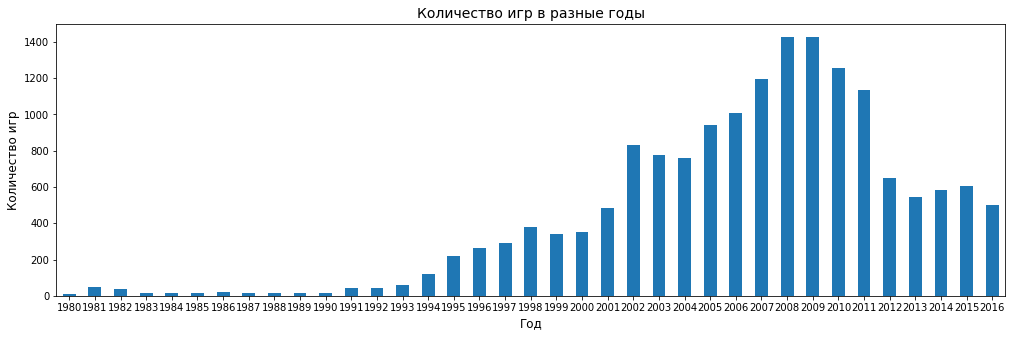

In [15]:
# делаем сводную таблицу - группируем по году и считаем количество игр
year_game = data.pivot_table(index='year_of_release', values='name', aggfunc='count')
year_game.columns = ['count']
print(year_game)

# строим вертикальную столбчатую диаграмму
year_game.plot(kind='bar', figsize=(17,5), rot=0, legend=False)
plt.title('Количество игр в разные годы', fontsize=14)
plt.ylabel('Количество игр', fontsize=12)
plt.xlabel('Год', fontsize=12)
plt.show()

Данные за все года не так важны для нашего исследования, так как за представленные 36 лет кардинально изменились и технологии, и популярные жанры, и сами игры (их геймплей и техническая составляющая).\
Поэтому важно выделить актуальный период для дальнейшего исследования. Обычно, чтобы увидеть какие-либо долгосрочные тенденции и изменения, для анализа выбирают период от 3 до 5 лет, мы же возьмем период в последние 4 года - с 2013 по 2016 гг включительно.

#### Изменения продаж по платформам

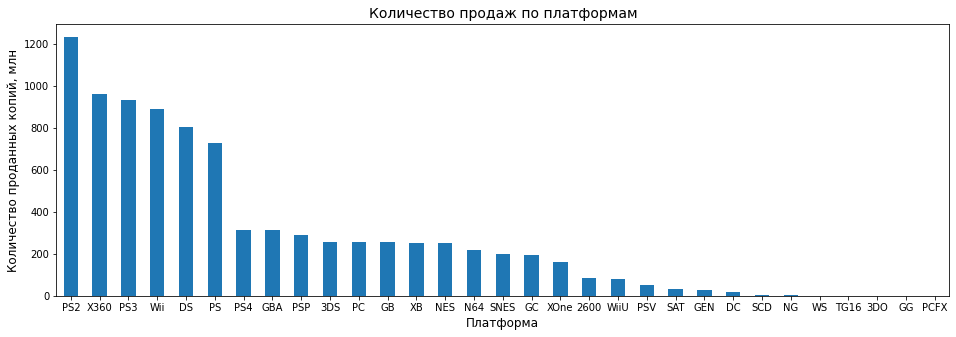

In [16]:
# делаем сводную таблицу - группируем по платформе и считаем количество игр
platform_sales = data.pivot_table(index='platform', values='total_sales', aggfunc='sum')
platform_sales.columns = ['sum']
platform_sales = platform_sales.sort_values(by='sum', ascending=False)

# строим вертикальную столбчатую диаграмму
platform_sales.plot(kind='bar', figsize=(16,5), rot=0, legend=False)
plt.title('Количество продаж по платформам', fontsize=14)
plt.ylabel('Количество проданных копий, млн', fontsize=12)
plt.xlabel('Платформа', fontsize=12)
plt.show()

К платформам с наибольшими суммарными продажами за весь период с 1985 года относятся: PS2, X360, PS3, Wii, DS, PS, PS4, GBA, PSP, 3DS (топ-15).

Возьмем топ-10 с наибольшими суммарными продажами и построим график.

In [17]:
platform_sales = platform_sales.head(10)
print(platform_sales)

              sum
platform         
PS2       1233.56
X360       961.24
PS3        931.33
Wii        891.18
DS         802.78
PS         727.58
PS4        314.14
GBA        312.88
PSP        289.53
3DS        257.81


,year_of_release,platform,total_sales_sum
0,1985,DS,0.02
1,1994,PS,6.03
2,1995,PS,35.96
3,1996,PS,94.70
4,1997,PS,136.17
...,...,...,...
92,2016,3DS,15.14
93,2016,PS3,3.60
94,2016,PS4,69.25
95,2016,Wii,0.18


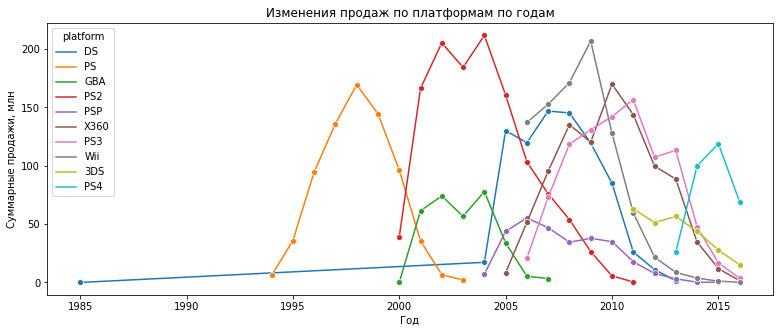

In [18]:
# создаем список с топ-10 платформами с наибольшими суммарными продажами
selected_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4', 'GBA', 'PSP', '3DS']
platforms_data = data[data['platform'].isin(selected_platforms)]

# группируем данные по году выпуска и платформе и суммируем общие продажи
year_platform_sales = platforms_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
year_platform_sales = year_platform_sales.rename(columns={'total_sales': 'total_sales_sum'})
display(year_platform_sales)

# строим линейный график по выбранным платформам
plt.figure(figsize=(13, 5))
sns.lineplot(data=year_platform_sales, x='year_of_release', y='total_sales_sum', hue='platform',  marker='o')
plt.xlabel('Год')
plt.ylabel('Суммарные продажи, млн')
plt.title('Изменения продаж по платформам по годам')
plt.show()

In [19]:
temp = data.copy() 
time_life = temp.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
time_life['life'] = time_life['max'] - time_life['min'] + 1 # в срок жизни платформы, должны входить границы диапазона, 
                                                            # поэтому +1
time_life['life'].median()

7.0


Средний срок "жизни" платформы из топа-10 платформ с наибольшими суммарными продажами равен 7 лет.

#### Исследование продаж по платформам за 2013-2016 гг

In [20]:
# сохраняем отдельный датафрейм с данными с 2013 года включительно
data_filtered = data.loc[data['year_of_release'] >= 2013]
display(data_filtered)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
...,...,...,...,...,...,...,...,...,...,...,...,...
16703,Strawberry Nauts,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16707,Aiyoku no Eustia,PSV,2014,Misc,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN,0.01


In [21]:
# смотрим, на какие платформы были продажи игр с 2013 года
data_filtered['platform'].unique()

array(['PS3', 'X360', 'PS4', '3DS', 'XOne', 'WiiU', 'Wii', 'PC', 'PSV',
       'DS', 'PSP'], dtype=object)

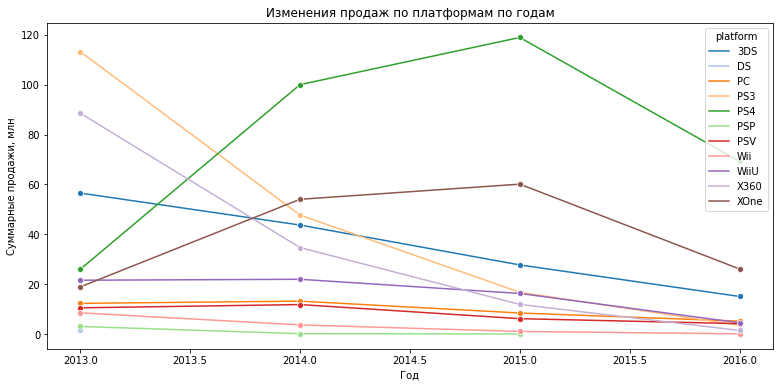

In [22]:
# группируем данные по году выпуска и платформе и суммируем общие продажи
year_sales = data_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index()
year_sales = year_sales.rename(columns={'total_sales': 'total_sales_sum'})

# строим линейный график изменения продаж по платформам в 2013-2016 гг
plt.figure(figsize=(13, 6))
sns.lineplot(data=year_sales, x='year_of_release', y='total_sales_sum', hue='platform',  marker='o',  palette='tab20')
plt.xlabel('Год')
plt.ylabel('Суммарные продажи, млн')
plt.title('Изменения продаж по платформам по годам')
plt.show()

Продажи игр на платформу DS последний раз были в 2013 году, а на платформу PSP - в 2015.

,total_sales_median
platform,
PSP,0.240
DS,1.540
Wii,2.445
PSV,8.420
PC,10.450
WiiU,19.000
X360,23.350
PS3,32.290
3DS,35.770


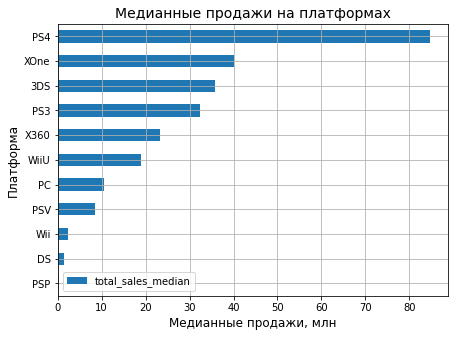

In [23]:
# посмотрим медианный уровень продаж за 2013-2014 года на этих платформах
comparison = year_sales.pivot_table(index='platform', values='total_sales_sum', aggfunc='median')
comparison = comparison.sort_values(by='total_sales_sum', ascending=True)
comparison.columns = ['total_sales_median']
display(comparison)

# строим горизонтальную столбчатую диаграмму
comparison.plot(kind='barh', figsize=(7,5), rot=0, grid=True)
plt.title('Медианные продажи на платформах', fontsize=14)
plt.ylabel('Платформа', fontsize=12)
plt.xlabel('Медианные продажи, млн', fontsize=12)
plt.show()

По продажам лидируют PS4 И XOne.\
С 2015 по 2016 продажи падали по всем платформам, но с 2013 по 2015 продажи росли у PS4 И XOne, а в период с 2013 по 2014 рост был и на платформах PC и PSV.


In [24]:
# сохраняем отдельные датафреймы с данными 2013 года и 2016 года
year_sales_2013 = year_sales.loc[year_sales['year_of_release'] == 2013]
year_sales_2016 = year_sales.loc[year_sales['year_of_release'] == 2016]

year_sales_13_16 = year_sales_2013.merge(year_sales_2016, on='platform', how='outer', suffixes=('_2013', '_2016'))
display(year_sales_13_16.head())

,year_of_release_2013,platform,total_sales_sum_2013,year_of_release_2016,total_sales_sum_2016
0,2013,3DS,56.57,2016.0,15.14
1,2013,DS,1.54,NaN,NaN
2,2013,PC,12.38,2016.0,5.25
3,2013,PS3,113.25,2016.0,3.60
4,2013,PS4,25.99,2016.0,69.25


In [25]:
year_sales_13_16['difference'] = year_sales_13_16['total_sales_sum_2013'] - year_sales_13_16['total_sales_sum_2016']
year_sales_13_16['difference_percent'] = round(((year_sales_13_16['total_sales_sum_2016'] -\
                                                 year_sales_13_16['total_sales_sum_2013'])\
                                                / year_sales_13_16['total_sales_sum_2013']) * 100, 1)
year_sales_13_16 = year_sales_13_16.sort_values(by='difference_percent', ascending=False)
display(year_sales_13_16)

,year_of_release_2013,platform,total_sales_sum_2013,year_of_release_2016,total_sales_sum_2016,difference,difference_percent
4,2013,PS4,25.99,2016.0,69.25,-43.26,166.4
10,2013,XOne,18.96,2016.0,26.15,-7.19,37.9
2,2013,PC,12.38,2016.0,5.25,7.13,-57.6
6,2013,PSV,10.59,2016.0,4.25,6.34,-59.9
0,2013,3DS,56.57,2016.0,15.14,41.43,-73.2
8,2013,WiiU,21.65,2016.0,4.60,17.05,-78.8
3,2013,PS3,113.25,2016.0,3.60,109.65,-96.8
7,2013,Wii,8.59,2016.0,0.18,8.41,-97.9
9,2013,X360,88.58,2016.0,1.52,87.06,-98.3
1,2013,DS,1.54,NaN,NaN,NaN,NaN


Наиболее потенциально прибыльными из данных платформ можно считать PS4, XOne, PC, PSV, так как у них на момент 2016 года наблюдается или рост по продажам, или спад не более 60% от продаж в 2013 году.\
Потери в продажах у остальных платформ более 70% от продаж 2013 году.

#### Глобальные продажи игр в разбивке по платформам


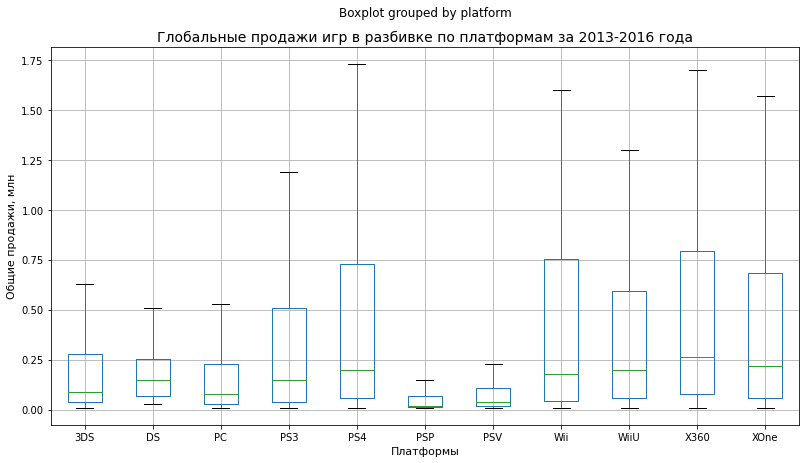

In [26]:
# строим боксплот по глобальным продажам игр в разбивке по платформам за 2013-2016 года
data_filtered.boxplot('total_sales', by='platform', figsize=(13,7), showfliers=False)
plt.title('Глобальные продажи игр в разбивке по платформам за 2013-2016 года', fontsize=14) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Платформы', fontsize=11)
plt.show()

По графику боксплота видно, что большее количество продаваемых игр предназначено для платформ: PS4, X360, Wii, XOne, WiiU, PS3.\
Совсем редко же покупают игры на PSP, немногим чаще на PSV.

#### Влияние отзывов пользователей и критиков на продажи внутри одной популярной платформы PS4	

In [27]:
# будем проводить исследование на основе самой популярной платформы PS4
# для этого сохраним данные по этой платформе за 2013-2016 гг в отдельный датафрейм
rating_ps4 = data_filtered.loc[data_filtered['platform'] == 'PS4']
display(rating_ps4.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,NaN,14.63
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
77,FIFA 16,PS4,2015,Sports,1.12,6.12,0.06,1.28,82.0,4.3,E,8.58
87,Star Wars Battlefront (2015),PS4,2015,Shooter,2.99,3.49,0.22,1.28,NaN,NaN,NaN,7.98
92,Call of Duty: Advanced Warfare,PS4,2014,Shooter,2.81,3.48,0.14,1.23,83.0,5.7,M,7.66


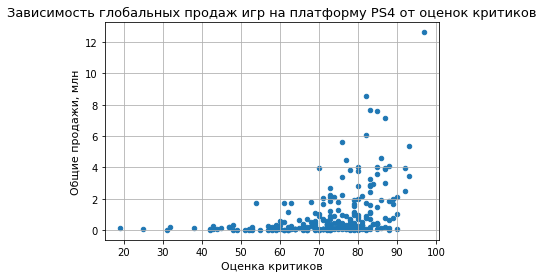

Коэффициент корреляции равен: 0.41


In [28]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PS4 от оценок критиков
rating_ps4.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PS4 от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_ps4['critic_score'].corr(rating_ps4['total_sales']), 2))

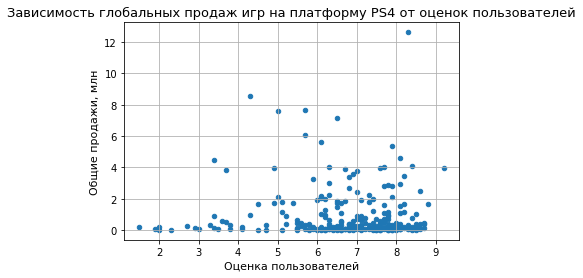

Коэффициент корреляции равен: -0.03


In [29]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PS4 от оценок пользователей
rating_ps4.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PS4 от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_ps4['user_score'].corr(rating_ps4['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы PS4 в слабой степени, так как коэффициент корреляции равен 0.41, то есть, чем выше оценка, тем больше продаж.\
И наоборот, отзывы пользователей не оказывают никакого влияния на продажи, коэффициент корреляции равен -0.03.

#### Влияние отзывов пользователей и критиков на продажи внутри других платформ

Проведем исследование и сравним зависимость между отзывами пользователей и критиков и продажами по платформам, данные по которым есть за 2013-2016 года.\
В список таких платформ войдут: XOne, PC, PSV, 3DS, WiiU, PS3, Wii, X360.\
Платформы DS и PSP не будем рассматривать, так как продажи игр на них завершились до конца исследуемого периода.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы XOne

In [30]:
# сохраним данные по платформе XOne за 2013-2016 гг в отдельный датафрейм
rating_xone = data_filtered.loc[data_filtered['platform'] == 'XOne']
display(rating_xone.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
99,Call of Duty: Black Ops 3,XOne,2015,Shooter,4.59,2.11,0.01,0.68,NaN,NaN,NaN,7.39
165,Grand Theft Auto V,XOne,2014,Action,2.81,2.19,0.00,0.47,97.0,7.9,M,5.47
179,Call of Duty: Advanced Warfare,XOne,2014,Shooter,3.22,1.55,0.01,0.48,81.0,5.4,M,5.26
242,Halo 5: Guardians,XOne,2015,Shooter,2.78,1.27,0.03,0.41,84.0,6.4,T,4.49
270,Fallout 4,XOne,2015,Role-Playing,2.51,1.32,0.01,0.38,88.0,6.2,M,4.22


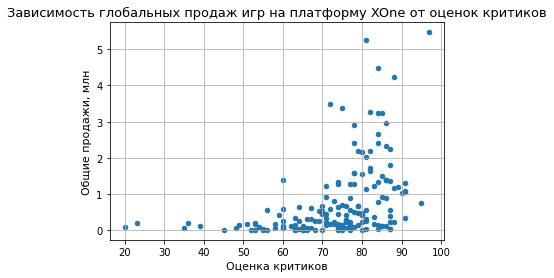

Коэффициент корреляции равен: 0.42


In [31]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу XOne от оценок критиков
rating_xone.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу XOne от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_xone['critic_score'].corr(rating_xone['total_sales']), 2))

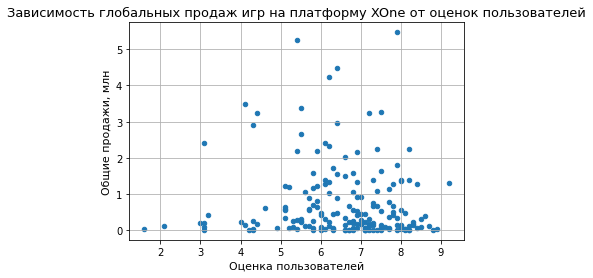

Коэффициент корреляции равен: -0.07


In [32]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу XOne от оценок пользователей
rating_xone.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу XOne от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_xone['user_score'].corr(rating_xone['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы XOne в слабой степени, так как коэффициент корреляции равен 0.42, то есть, чем выше оценка, тем больше продаж.\
И наоборот, отзывы пользователей не оказывают никакого влияния на продажи, коэффициент корреляции равен -0.07.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы PC

In [33]:
# сохраним данные по платформе PC за 2013-2016 гг в отдельный датафрейм
rating_pc = data_filtered.loc[data_filtered['platform'] == 'PC']
display(rating_pc.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
458,The Sims 4,PC,2014,Simulation,1.00,1.82,0.0,0.23,70.0,3.9,T,3.05
1095,StarCraft II: Heart of the Swarm,PC,2013,Strategy,0.83,0.66,0.0,0.18,86.0,7.9,T,1.67
1351,SimCity (2013),PC,2013,Simulation,0.48,0.77,0.0,0.17,64.0,2.2,E10+,1.42
1437,Battlefield 4,PC,2013,Shooter,0.39,0.87,0.0,0.10,81.0,6.0,M,1.36
1530,Fallout 4,PC,2015,Role-Playing,0.51,0.67,0.0,0.10,84.0,5.4,M,1.28


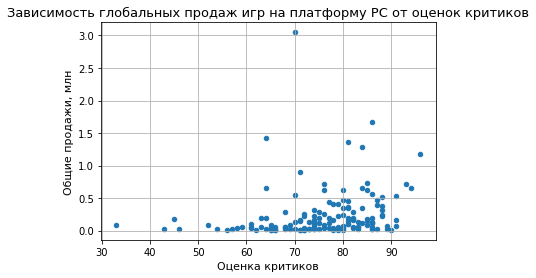

Коэффициент корреляции равен: 0.2


In [34]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PC от оценок критиков
rating_pc.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PC от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_pc['critic_score'].corr(rating_pc['total_sales']), 2))

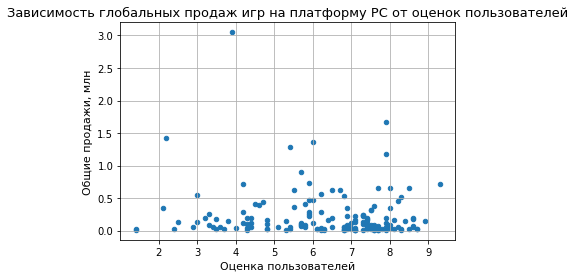

Коэффициент корреляции равен: -0.09


In [35]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PC от оценок пользователей
rating_pc.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PC от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_pc['user_score'].corr(rating_pc['total_sales']), 2))

Можно сделать вывод, что отзывы критиков очень слабо влияют на продажи игр внутри платформы PC, так как коэффициент корреляции равен 0.2.\
Также отзывы пользователей не оказывают никакого влияния на продажи, коэффициент корреляции равен -0.09.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы PSV

In [36]:
# сохраним данные по платформе PSV за 2013-2016 гг в отдельный датафрейм
rating_psv = data_filtered.loc[data_filtered['platform'] == 'PSV']
display(rating_psv.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
868,Minecraft,PSV,2014,Misc,0.18,0.64,0.90,0.24,NaN,NaN,NaN,1.96
2566,Killzone: Mercenary,PSV,2013,Shooter,0.20,0.39,0.04,0.17,78.0,8.9,M,0.80
2569,Final Fantasy X / X-2 HD Remaster,PSV,2013,Role-Playing,0.16,0.24,0.28,0.12,86.0,8.5,T,0.80
3086,Freedom Wars,PSV,2014,Role-Playing,0.15,0.10,0.32,0.08,73.0,8.3,T,0.65
3127,Borderlands 2,PSV,2014,Shooter,0.32,0.16,0.01,0.15,64.0,7.6,M,0.64


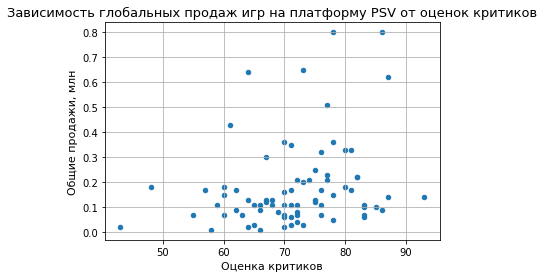

Коэффициент корреляции равен: 0.25


In [37]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PSV от оценок критиков
rating_psv.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PSV от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_psv['critic_score'].corr(rating_psv['total_sales']), 2))

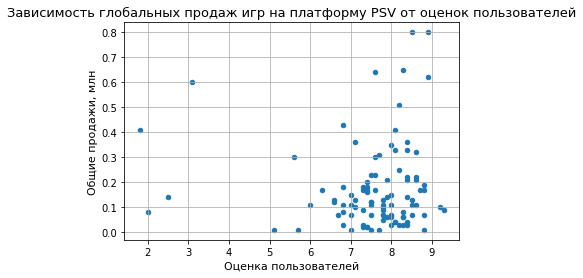

Коэффициент корреляции равен: 0.0


In [38]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу PSV от оценок пользователей
rating_psv.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PSV от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_psv['user_score'].corr(rating_psv['total_sales']), 2))

Можно сделать вывод, что отзывы критиков очень слабо влияют на продажи игр внутри платформы PSV, так как коэффициент корреляции равен 0.25.\
Также отзывы пользователей не оказывают никакого влияния на продажи, коэффициент корреляции равен 0.0.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы 3DS

In [39]:
# сохраним данные по платформе 3DS за 2013-2016 гг в отдельный датафрейм
rating_3ds = data_filtered.loc[data_filtered['platform'] == '3DS']
display(rating_3ds.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
33,Pokemon X/Pokemon Y,3DS,2013,Role-Playing,5.28,4.19,4.35,0.78,NaN,NaN,NaN,14.60
47,Pokemon Omega Ruby/Pokemon Alpha Sapphire,3DS,2014,Role-Playing,4.35,3.49,3.10,0.74,NaN,NaN,NaN,11.68
96,Super Smash Bros. for Wii U and 3DS,3DS,2014,Fighting,3.27,1.37,2.43,0.48,NaN,NaN,NaN,7.55
108,Pokemon Sun/Moon,3DS,2016,Role-Playing,2.98,1.45,2.26,0.45,NaN,NaN,NaN,7.14
184,Tomodachi Life,3DS,2013,Simulation,0.97,2.11,1.90,0.24,NaN,NaN,NaN,5.22


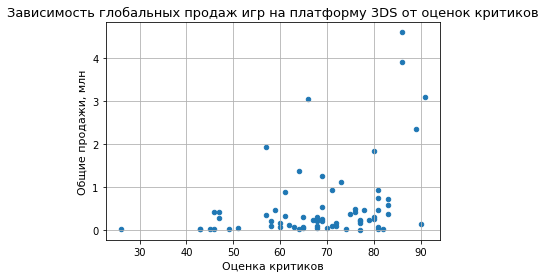

Коэффициент корреляции равен: 0.36


In [40]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу 3DS от оценок критиков
rating_3ds.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу 3DS от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_3ds['critic_score'].corr(rating_3ds['total_sales']), 2))

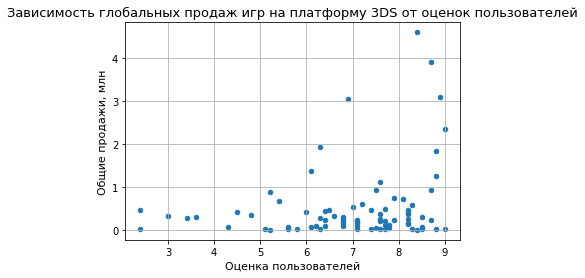

Коэффициент корреляции равен: 0.24


In [41]:
# строим диаграмму рассеивания - зависимость глобальных продаж игр на платформу 3DS от оценок пользователей
rating_3ds.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу 3DS от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_3ds['user_score'].corr(rating_3ds['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы 3DS в слабой степени, так как коэффициент корреляции равен 0.36, то есть с увеличением значения оценки, стоимость игр немного тоже увеличивается.\
Отзывы пользователей же оказывают очень слабое влияние на продажи, так как коэффициент корреляции равен 0.24.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы WiiU

In [42]:
# сохраним данные по платформе WiiU за 2013-2016 гг в отдельный датафрейм
rating_wiiu = data_filtered.loc[data_filtered['platform'] == 'WiiU']
display(rating_wiiu.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
110,Mario Kart 8,WiiU,2014,Racing,3.15,2.15,1.28,0.51,88.0,9.1,E,7.09
216,Super Smash Bros. for Wii U and 3DS,WiiU,2014,Fighting,2.60,1.08,0.81,0.38,NaN,NaN,NaN,4.87
247,Splatoon,WiiU,2015,Shooter,1.54,1.18,1.46,0.26,81.0,8.5,E10+,4.44
260,Super Mario 3D World,WiiU,2013,Platform,2.11,1.16,0.73,0.32,93.0,9.0,E,4.32
424,Super Mario Maker,WiiU,2015,Platform,1.18,0.89,0.94,0.20,88.0,8.7,E,3.21


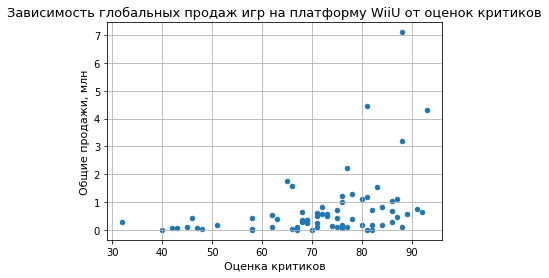

Коэффициент корреляции равен: 0.38


In [43]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок критиков
rating_wiiu.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу WiiU от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_wiiu['critic_score'].corr(rating_wiiu['total_sales']), 2))

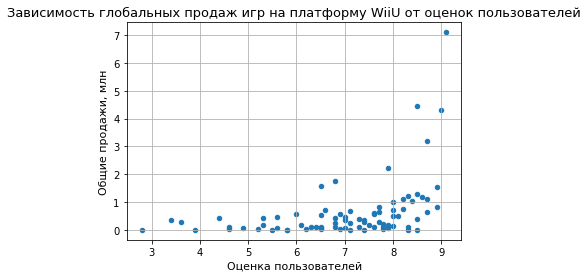

Коэффициент корреляции равен: 0.42


In [44]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок пользователей
rating_wiiu.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу WiiU от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_wiiu['user_score'].corr(rating_wiiu['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы WiiU в слабой степени, так как коэффициент корреляции равен 0.38, то есть с увеличением значения оценки, стоимость игр немного тоже увеличивается.\
Отзывы пользователей также оказывают слабое влияние на продажи, так как коэффициент корреляции равен 0.42.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы PS3

In [45]:
# сохраним данные по платформе PS3 за 2013-2016 гг в отдельный датафрейм
rating_ps3 = data_filtered.loc[data_filtered['platform'] == 'PS3']
display(rating_ps3.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36
126,FIFA 14,PS3,2013,Sports,0.78,4.24,0.07,1.37,86.0,4.3,E,6.46
149,The Last of Us,PS3,2013,Action,2.41,2.18,0.28,0.99,95.0,9.1,M,5.86
180,Minecraft,PS3,2014,Misc,2.03,2.37,0.00,0.87,NaN,NaN,NaN,5.27


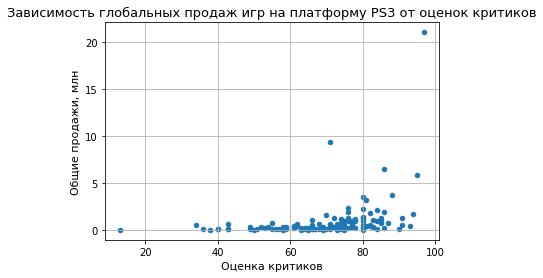

Коэффициент корреляции равен: 0.33


In [46]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок критиков
rating_ps3.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PS3 от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_ps3['critic_score'].corr(rating_ps3['total_sales']), 2))

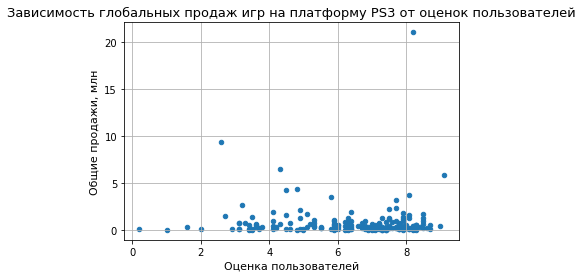

Коэффициент корреляции равен: 0.0


In [47]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок пользователей
rating_ps3.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу PS3 от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_ps3['user_score'].corr(rating_ps3['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы PS3 в слабой степени, так как коэффициент корреляции равен 0.33.\
Отзывы пользователей же не оказывают никакого влияния на продажи, так как коэффициент корреляции равен 0.0.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы Wii

In [48]:
# сохраним данные по платформе Wii за 2013-2016 гг в отдельный датафрейм
rating_wii = data_filtered.loc[data_filtered['platform'] == 'Wii']
display(rating_wii.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
359,Just Dance 2014,Wii,2013,Misc,1.88,1.39,0.0,0.31,NaN,6.2,E10+,3.58
766,Skylanders SWAP Force,Wii,2013,Platform,1.21,0.75,0.0,0.19,NaN,6.6,E10+,2.15
850,Just Dance 2015,Wii,2014,Misc,0.99,0.85,0.0,0.17,NaN,8.4,E10+,2.01
1158,Disney Infinity,Wii,2013,Action,1.05,0.41,0.0,0.14,NaN,4.2,E10+,1.60
2179,Just Dance 2016,Wii,2015,Misc,0.41,0.46,0.0,0.08,NaN,NaN,E10+,0.95


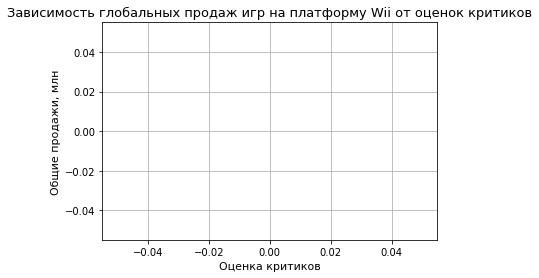

Коэффициент корреляции равен: nan


In [49]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок критиков
rating_wii.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу Wii от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_wii['critic_score'].corr(rating_wii['total_sales']), 2))

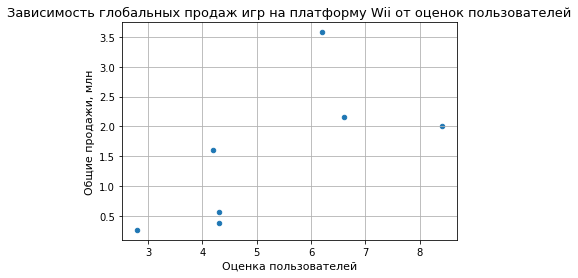

Коэффициент корреляции равен: 0.68


In [50]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок пользователей
rating_wii.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу Wii от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_wii['user_score'].corr(rating_wii['total_sales']), 2))

К сожалению, нельзя сделать вывод о влиянии отзывов критиков на продажи игр внутри платформы Wii, так как эти данные отсутствуют.\
Но видно, что отзывы пользователей оказывают среднее прямо пропорциональное влияние на продажи, так как коэффициент корреляции равен 0.68.

##### Влияние отзывов пользователей и критиков на продажи внутри других платформы X360

In [51]:
# сохраним данные по платформе X360 за 2013-2016 гг в отдельный датафрейм
rating_x360 = data_filtered.loc[data_filtered['platform'] == 'X360']
display(rating_x360.head())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24
72,Minecraft,X360,2013,Misc,5.70,2.65,0.02,0.81,NaN,NaN,NaN,9.18
263,Call of Duty: Advanced Warfare,X360,2014,Shooter,2.77,1.11,0.00,0.40,NaN,4.9,M,4.28
271,FIFA 14,X360,2013,Sports,0.92,2.89,0.01,0.40,84.0,4.2,E,4.22


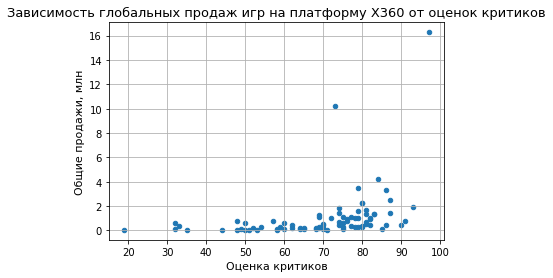

Коэффициент корреляции равен: 0.35


In [52]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок критиков
rating_x360.plot(x='critic_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу X360 от оценок критиков', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка критиков', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_x360['critic_score'].corr(rating_x360['total_sales']), 2))

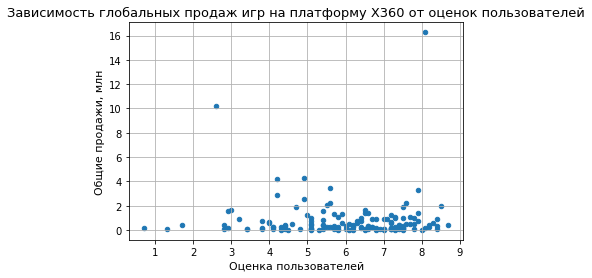

Коэффициент корреляции равен: -0.01


In [53]:
# строим диаграмму рассеивания - зависимость глобальных продаж от оценок пользователей
rating_x360.plot(x='user_score', y='total_sales', kind='scatter', grid=True)
plt.title('Зависимость глобальных продаж игр на платформу X360 от оценок пользователей', fontsize=13) # добавила подписи
plt.ylabel('Общие продажи, млн', fontsize=11)
plt.xlabel('Оценка пользователей', fontsize=11)
plt.show()

print('Коэффициент корреляции равен:', round(rating_x360['user_score'].corr(rating_x360['total_sales']), 2))

Можно сделать вывод, что отзывы критиков влияют на продажи игр внутри платформы X360 в слабой степени, так как коэффициент корреляции равен 0.35.\
Отзывы пользователей же не оказывают никакого влияния на продажи, так как коэффициент корреляции равен -0.01.

##### Вывод 

Из исследований в пунктах 3.5 и 3.6.1-3.6.8 следует заключение:
1) оценка критиков в минимум 88.8%* рассмотренных нами случаев влияет на продажи игр по самым разным платформам, как по самым популярным и перспективным (таким как, PS4 или XOne), так и по наменее востребованным (например, PSV);\
2) в рассмотренных случаях взаимосвязь между оценками критиков и глобальными продажами характеризуется коэффициентом корреляции, равным 0,2-0,42, что говорит об очень слабой или слабой степени прямой зависимости (по шкале Чеддока);\
3) оценка пользователей же влияет на продажи игр только в 33,3% случаев из рассмотренных нами, в этих случаях коэффициент корреляции равен 0,24-0,68, что указывает на большой разброс в степени влияния (от очень слабого до среднего);\
4) при этом в большей части случаев оценка пользователей никак не влияет на глобальные продажи игр по платформам, так как в 66,7% случаев коэффициент корреляции был примерно равен 0.

- *т.к. по одной платформе (Wii) нет данных об оценках критиков

#### Исследование распределений игр и продаж по жанрам

##### Общее распределение игр по жанрам

In [54]:
# в сводную таблицу группируем игры по жанрам за актуальный период, считая их количество
genre_games = data_filtered.pivot_table(index='genre', values='name', aggfunc='count')
genre_games.columns = ['count']
genre_games = genre_games.sort_values(by='count', ascending=True)
display(genre_games)

,count
genre,
Puzzle,17
Strategy,56
Simulation,62
Platform,74
Fighting,80
Racing,85
Misc,155
Shooter,187
Sports,214


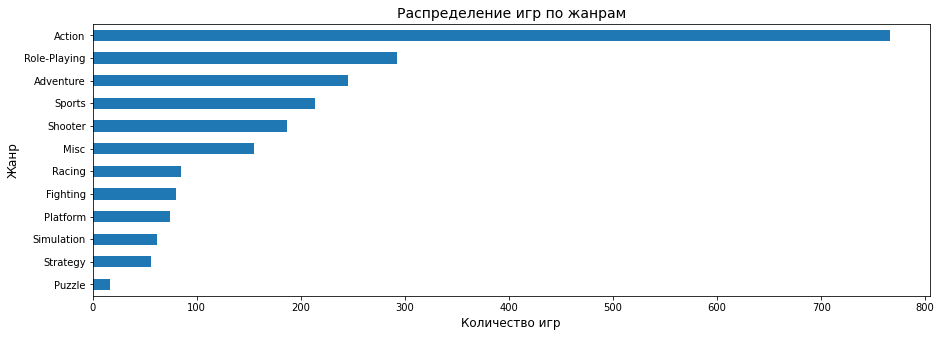

In [55]:
# строим горизонтальную столбчатую диаграмму
genre_games.plot(kind='barh', figsize=(15,5), rot=0, legend=False)
plt.title('Распределение игр по жанрам', fontsize=14)
plt.ylabel('Жанр', fontsize=12)
plt.xlabel('Количество игр', fontsize=12)
plt.show()

Больше всего игр, выпущенных в 2013-2016 гг, относятся к жанру Action (766), в 2.6 раз меньше к следующему по количеству игр жанру - Role-Playing или RPG (292 игры).\
Меньше всего - к Puzzle или головоломкам (всего 17 игр).

##### Глобальные продажи игр в разбивке по жанрам

In [56]:
# в сводную таблицу группируем глобальные продажи по жанрам за актуальный период, считая их количество
genre_sales = data_filtered.pivot_table(index='genre', values='total_sales', aggfunc='median')
genre_sales.columns = ['median']
genre_sales = genre_sales.sort_values(by='median', ascending=True)
display(genre_sales)

,median
genre,
Adventure,0.030
Puzzle,0.060
Strategy,0.080
Misc,0.100
Simulation,0.100
Action,0.110
Racing,0.120
Fighting,0.125
Role-Playing,0.125


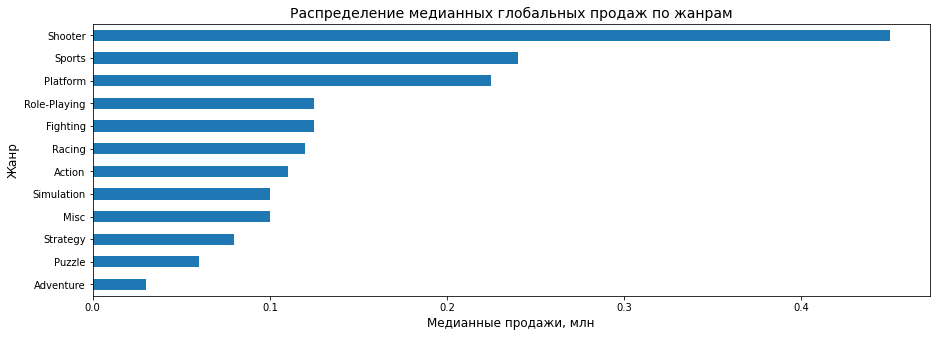

In [57]:
# строим горизонтальную столбчатую диаграмму
genre_sales.plot(kind='barh', figsize=(15,5), rot=0, legend=False)
plt.title('Распределение медианных глобальных продаж по жанрам', fontsize=14)
plt.ylabel('Жанр', fontsize=12)
plt.xlabel('Медианные продажи, млн', fontsize=12)
plt.show()

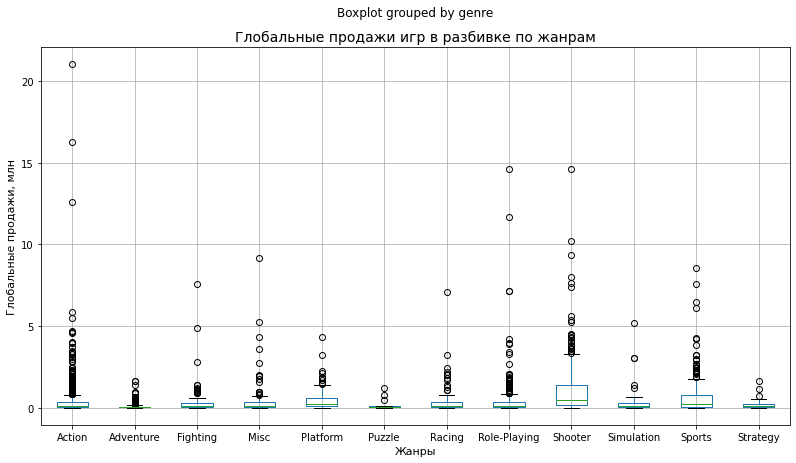

In [58]:
# строим диаграммы размаха по глобальным продажам игр в разбивке по жанрам, включая выбросы
data_filtered.boxplot('total_sales', by='genre', figsize=(13,7))
plt.title('Глобальные продажи игр в разбивке по жанрам', fontsize=14)
plt.ylabel('Глобальные продажи, млн', fontsize=11)
plt.xlabel('Жанры', fontsize=11)
plt.show()

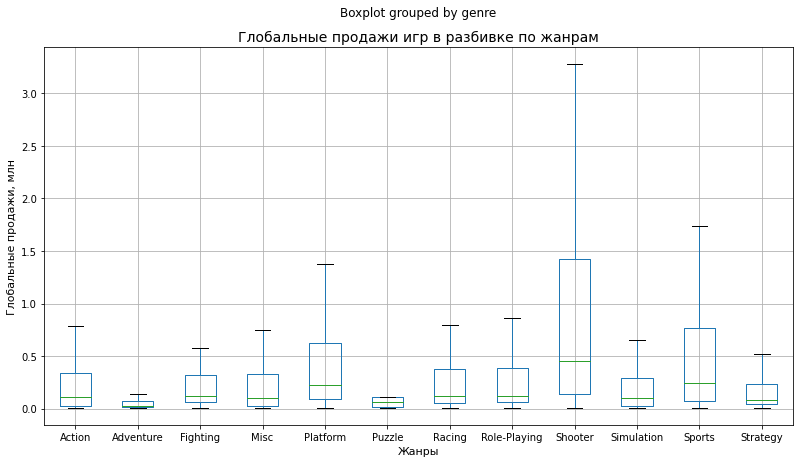

In [59]:
# строим диаграммы размаха по глобальным продажам игр в разбивке по жанрам без выбросов
data_filtered.boxplot('total_sales', by='genre', figsize=(13,7), showfliers=False)
plt.title('Глобальные продажи игр в разбивке по жанрам', fontsize=14)
plt.ylabel('Глобальные продажи, млн', fontsize=11)
plt.xlabel('Жанры', fontsize=11)
plt.show()

Из исследований выше можно сделать следующие выводы:
1) наибольшее количество выпущенных игр в период с 2013 по 2016 год относится к жанру Action, так же этот жанр можно назвать самым прибыльным и популярным, так как было продано 321.87 млн копий игр этого жанра;\
2) хотя жанр Role-Playing или RPG по количеству выпущенных игр находится на втором месте, по глобальным продажам он всего на четвертом месте после таких жанров как Shooter и Sports, по которым игр было выпущено меньше за этот период;\
3) самым непопулярным жанром оказался Puzzle или головоломки - по нему вышло всего 17 игр, а было продано 3.17 млн копий.

Несмотря на то, что есть несколько игр жанра Action, которые "выстрелили" по количеству проданных копий по сравнению с другими жанрами, он входит лишь в топ-7 популярных жанров.\
Хотя жанр Role-Playing или RPG по количеству выпущенных игр находится на втором месте, по глобальным продажам он всего на четвертом месте.\
\
А вот по медианным продажам в мире заметно выделяется жанр Shooter, и его можно назвать наиболее прибыльным за 2013-2016 года.\
После него по медианным продажам с большой разницей по сравнению с ним и со сравнительно большим отрывом от других жанров, но примерно на одном уровне находятся жанры Sports и Platform. Эти жанры также можно отнести к прибыльным и перспективным.\
Наименее популярными и прибыльными же являются игры жанра Adventure.

##### Вывод

### Шаг 4. Портрет пользователя каждого региона

#### Самые популярные платформы (топ-5)

In [60]:
# смотрим, какие платформы входят в топ-5 по регионам, чтобы потом оставшиеся сгруппировать в одну категорию "Другие"

# с помощью сводной таблицы смотрим распределение продаж в Северной Америке по платформам
top5_platforms_na = data_filtered.pivot_table(index='platform', values='na_sales', aggfunc='sum')
top5_platforms_na = top5_platforms_na.sort_values(by='na_sales', ascending=False)
print(top5_platforms_na)

# с помощью сводной таблицы смотрим распределение продаж в Европе по платформам
top5_platforms_eu = data_filtered.pivot_table(index='platform', values='eu_sales', aggfunc='sum')
top5_platforms_eu = top5_platforms_eu.sort_values(by='eu_sales', ascending=False)
print(top5_platforms_eu)

# с помощью сводной таблицы смотрим распределение продаж в Японии по платформам
top5_platforms_jp = data_filtered.pivot_table(index='platform', values='jp_sales', aggfunc='sum')
top5_platforms_jp = top5_platforms_jp.sort_values(by='jp_sales', ascending=False)
print(top5_platforms_jp)

          na_sales
platform          
PS4         108.74
XOne         93.12
X360         81.66
PS3          63.50
3DS          38.20
WiiU         29.21
PC           11.11
Wii           6.56
PSV           5.04
DS            0.57
PSP           0.00
          eu_sales
platform          
PS4         141.09
PS3          67.81
XOne         51.59
X360         42.52
3DS          30.96
PC           25.36
WiiU         19.85
PSV           6.10
Wii           5.93
DS            0.85
PSP           0.17
          jp_sales
platform          
3DS          67.81
PS3          23.35
PSV          18.59
PS4          15.96
WiiU         10.88
PSP           3.29
X360          0.51
XOne          0.34
Wii           0.05
DS            0.00
PC            0.00


In [61]:
# сохраняем копию датафрейма за 2013-2016 года и в ней все платформы, 
# которые не входят в топ-5 из сводной таблицы для Северной Америки, переименовываем в "Другие"
data_filtered1 = data_filtered.copy()
data_filtered1.loc[data_filtered1['platform'].isin(['PSP', 'DS', 'PSV', 'Wii', 'PC', 'WiiU']), 'platform'] = 'Другие'

# перезаписываем в сводную таблицу распределение продаж по платформам в Северной Америке 
# только уже все, кроме топ-5, группируются в одтельную категорию "Другие"
top5_platforms_na = data_filtered1.pivot_table(index='platform', values='na_sales', aggfunc='sum')
top5_platforms_na = top5_platforms_na.sort_values(by='na_sales', ascending=False)
print(top5_platforms_na)

          na_sales
platform          
PS4         108.74
XOne         93.12
X360         81.66
PS3          63.50
Другие       52.49
3DS          38.20


In [62]:
# так как топ-5 платформ одинаков для Северной Америки и Европы, новую копию
# датафрейма отдельно для Европы создавать не надо

# перезаписываем в сводную таблицу распределение продаж по платформам в Европе, включая новую категорию платформ "Другие"
top5_platforms_eu = data_filtered1.pivot_table(index='platform', values='eu_sales', aggfunc='sum')
top5_platforms_eu = top5_platforms_eu.sort_values(by='eu_sales', ascending=False)
print(top5_platforms_eu)

          eu_sales
platform          
PS4         141.09
PS3          67.81
Другие       58.26
XOne         51.59
X360         42.52
3DS          30.96


In [63]:
# сохраняем еще одну копию датафрейма для Японии, в которой все платформы,
# кроме топ-5, переименовываем в "Другие" по аналогии как делали выше
data_filtered2 = data_filtered.copy()
data_filtered2.loc[data_filtered2['platform'].isin(['PC', 'DS', 'Wii', 'XOne', 'X360', 'PSP']), 'platform'] = 'Другие'

# перезаписываем в сводную таблицу распределение продаж по платформам в Японии, включая новую категорию платформ "Другие"
top5_platforms_jp = data_filtered2.pivot_table(index='platform', values='jp_sales', aggfunc='sum')
top5_platforms_jp = top5_platforms_jp.sort_values(by='jp_sales', ascending=False)
print(top5_platforms_jp)

          jp_sales
platform          
3DS          67.81
PS3          23.35
PSV          18.59
PS4          15.96
WiiU         10.88
Другие        4.19


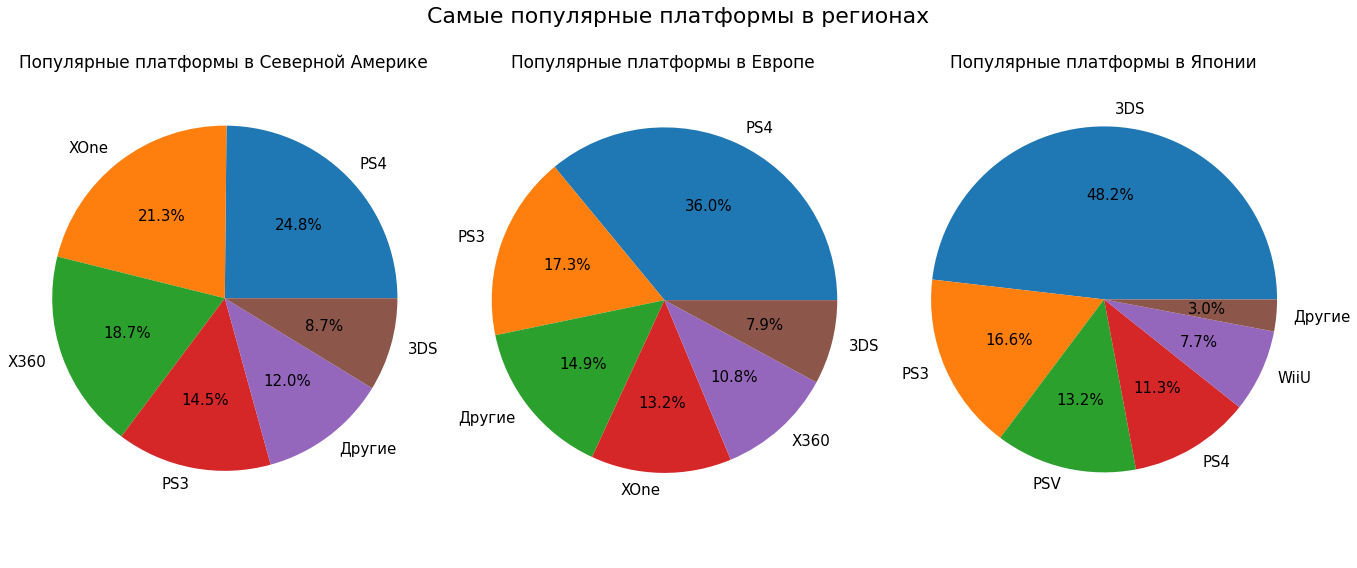

In [64]:
# строим круговые диаграммы с долями по сводным таблицам по регионам

plt.figure(figsize=(19,8))
plt.suptitle('Самые популярные платформы в регионах', fontsize=22)

# по Северной Америке
plt.subplot(1, 3, 1)
plt.pie(top5_platforms_na['na_sales'], labels=top5_platforms_na.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные платформы в Северной Америке', fontsize=17, y=0.93)
plt.axis('equal') 

# по Европе
plt.subplot(1, 3, 2)
plt.pie(top5_platforms_eu['eu_sales'], labels=top5_platforms_eu.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные платформы в Европе', fontsize=17, y=0.93)
plt.axis('equal') 

# по Японии
plt.subplot(1, 3, 3)
plt.pie(top5_platforms_jp['jp_sales'], labels=top5_platforms_jp.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные платформы в Японии', fontsize=17, y=0.93)
plt.axis('equal') 

plt.tight_layout()
plt.show()

Самыми популярными платформами в Северной Америке являются PS4, XOne, X360, PS3 и 3DS. На них приходится 88% продаж игр по всем платформам за 2013-2016 гг.\
В топ-5 популярных платформ в Европе входят те же платформы: PS4, PS3, XOne, X360 и 3DS, но на них в этом регоне приходится 85,2% продаж за актуальный период.\
К самым популярным платформам в Японии же относятся 3DS, PS3, PSV, PS4, WiiU, на которые приходится 97% продаж.\
\
\
Если сравнивать по платформам, то: 
* PS4 в Северной Америке занимает 24.8% продаж, в Европе 36%, а в Японии 11.3%
* XOne в Северной Америке занимает 21.3% продаж, в Европе 13.2%, а в Японии не входит в топ-5 популярных платформ
* X360 в Северной Америке занимает 18.7% продаж, в Европе 10.8%, а в Японии не входит в топ-5 популярных платформ
* PS3 в Северной Америке занимает 14.5% продаж, в Европе 17.3%, а в Японии 16.6%
* 3DS в Северной Америке занимает 8.7% продаж, в Европе 7.9%, а в Японии 48.2%
* в отличие от Северной Америки и Европы в Японии в топ-5 популярных платформ входят другие две платформы: PSV (13.2%) и WiiU (7.7%).

#### Самые популярные жанры (топ-5)

In [65]:
# смотрим, какие жанры входят в топ-5 по регионам, чтобы потом оставшиеся сгруппировать в одну категорию "Другие"

# с помощью сводной таблицы смотрим распределение продаж в Северной Америке по жанрам
top5_genres_na = data_filtered.pivot_table(index='genre', values='na_sales', aggfunc='sum')
top5_genres_na = top5_genres_na.sort_values(by='na_sales', ascending=False)
print(top5_genres_na)

# с помощью сводной таблицы смотрим распределение продаж в Европе по жанрам
top5_genres_eu = data_filtered.pivot_table(index='genre', values='eu_sales', aggfunc='sum')
top5_genres_eu = top5_genres_eu.sort_values(by='eu_sales', ascending=False)
print(top5_genres_eu)

# с помощью сводной таблицы смотрим распределение продаж в Японии по жанрам
top5_genres_jp = data_filtered.pivot_table(index='genre', values='jp_sales', aggfunc='sum')
top5_genres_jp = top5_genres_jp.sort_values(by='jp_sales', ascending=False)
print(top5_genres_jp)

              na_sales
genre                 
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Platform         18.14
Fighting         15.55
Racing           12.96
Adventure         7.14
Simulation        4.86
Strategy          3.28
Puzzle            0.83
              eu_sales
genre                 
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Misc             20.04
Platform         15.58
Simulation       10.92
Fighting          8.55
Adventure         8.25
Strategy          4.22
Puzzle            1.00
              jp_sales
genre                 
Role-Playing     51.04
Action           40.49
Misc              9.20
Fighting          7.65
Shooter           6.61
Adventure         5.82
Sports            5.41
Platform          4.79
Simulation        4.52
Racing            2.30
Strategy          1.77
Puzzle            1.18


In [66]:
# сохраняем копию датафрейма за 2013-2016 года и в ней все жанры, 
# которые не входят в топ-5 из сводной таблицы для Северной Америки, переименовываем в "Другие"
data_filtered3 = data_filtered.copy()
data_filtered3.loc[data_filtered3['genre'].isin(['Puzzle', 'Strategy', 'Simulation',\
                                                 'Adventure', 'Racing', 'Fighting', 'Platform']), 'genre'] = 'Другие'

# перезаписываем в сводную таблицу распределение продаж по жанрам в Северной Америке 
# только уже все, кроме топ-5, группируются в одтельную категорию "Другие"
top5_genres_na = data_filtered3.pivot_table(index='genre', values='na_sales', aggfunc='sum')
top5_genres_na = top5_genres_na.sort_values(by='na_sales', ascending=False)
print(top5_genres_na)

              na_sales
genre                 
Action          126.05
Shooter         109.74
Sports           65.27
Другие           62.76
Role-Playing     46.40
Misc             27.49


In [67]:
# сохраняем еще одну копию датафрейма для Европы, в которой все жанры,
# кроме топ-5, переименовываем в "Другие"
data_filtered4 = data_filtered.copy()
data_filtered4.loc[data_filtered4['genre'].isin(['Puzzle', 'Strategy', 'Adventure',\
                                                 'Fighting', 'Simulation', 'Platform', 'Misc']), 'genre'] = 'Другие'

# перезаписываем в сводную таблицу распределение продаж по жанрам в Европе, включая новую категорию "Другие"
top5_genres_eu = data_filtered4.pivot_table(index='genre', values='eu_sales', aggfunc='sum')
top5_genres_eu = top5_genres_eu.sort_values(by='eu_sales', ascending=False)
print(top5_genres_eu)

              eu_sales
genre                 
Action          118.13
Shooter          87.86
Другие           68.56
Sports           60.52
Role-Playing     36.97
Racing           20.19


In [68]:
# сохраняем еще одну копию датафрейма для Японии, в которой все жанры,
# кроме топ-5, переименовываем в "Другие"
data_filtered5 = data_filtered.copy()
data_filtered5.loc[data_filtered5['genre'].isin(['Puzzle', 'Strategy', 'Racing',\
                                                 'Simulation', 'Platform', 'Sports', 'Adventure']), 'genre'] = 'Другие'

# перезаписываем в сводную таблицу распределение продаж по жанрам в Японии, включая новую категорию "Другие"
top5_genres_jp = data_filtered5.pivot_table(index='genre', values='jp_sales', aggfunc='sum')
top5_genres_jp = top5_genres_jp.sort_values(by='jp_sales', ascending=False)
print(top5_genres_jp)

              jp_sales
genre                 
Role-Playing     51.04
Action           40.49
Другие           25.79
Misc              9.20
Fighting          7.65
Shooter           6.61


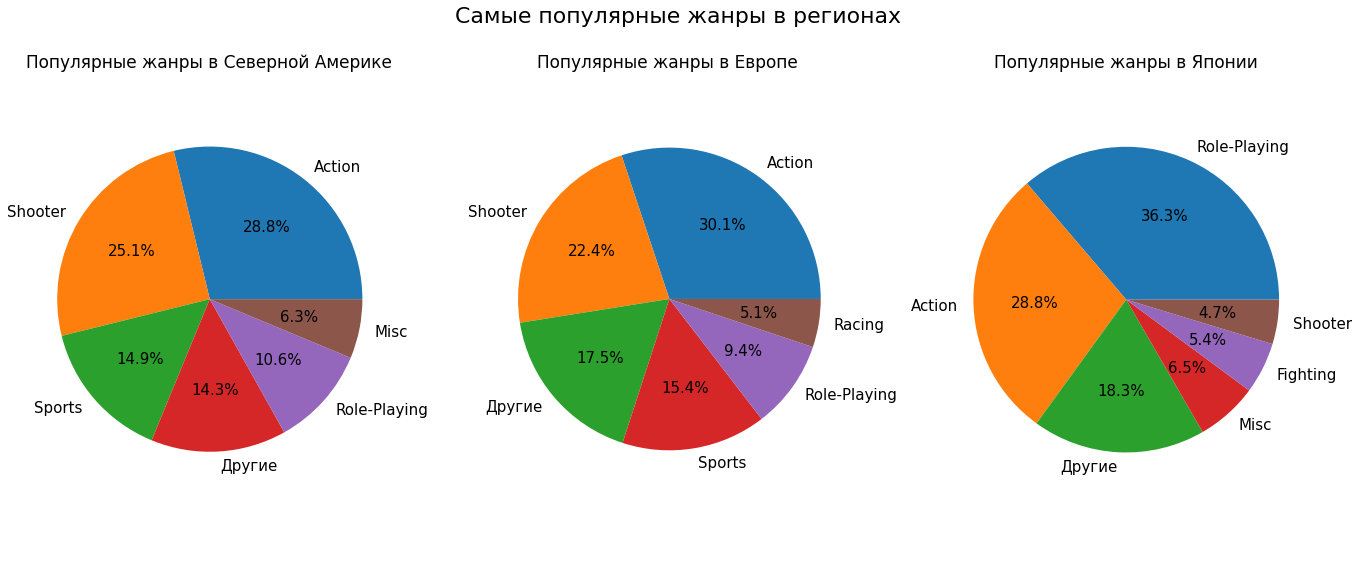

In [69]:
# строим круговые диаграммы с долями по сводным таблицам по регионам

plt.figure(figsize=(19,8))
plt.suptitle('Самые популярные жанры в регионах', fontsize=22)

# по Северной Америке
plt.subplot(1, 3, 1)
plt.pie(top5_genres_na['na_sales'], labels=top5_genres_na.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные жанры в Северной Америке', fontsize=17, y=0.93)
plt.axis('equal') 

# по Европе
plt.subplot(1, 3, 2)
plt.pie(top5_genres_eu['eu_sales'], labels=top5_genres_eu.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные жанры в Европе', fontsize=17, y=0.93)
plt.axis('equal') 

# по Японии
plt.subplot(1, 3, 3)
plt.pie(top5_genres_jp['jp_sales'], labels=top5_genres_jp.index, autopct='%1.1f%%', \
        textprops={'fontsize': 15}, labeldistance=1.1)
plt.title('Популярные жанры в Японии', fontsize=17, y=0.93)
plt.axis('equal') 

plt.tight_layout()
plt.show()

Самыми популярными жанрами в Северной Америке являются Action, Shooter, Sports, Role-Playing и Misc. На них приходится 85.7% продаж игр по всем жанрам за 2013-2016 гг.\
В топ-5 популярных жанров в Европе входят жанры: Action, Shooter, Sports, Role-Playing и Racing, на них в этом регоне приходится 82.4% продаж за актуальный период.\
К самым популярным жанрам в Японии же относятся Role-Playing, Action, Misc, Fighting, Shooter, на которые приходится 81.7% продаж.\
\
\
В Северной Америке в топ-5 жанров входит жанр Misc, что скорее всего означает "Miscellaneous" и обобщает широкий спектр игр без определенной тематики, а в Европе вместо него Racing, это возможно объясняется культурными предпочтениями игроков.\
\
Японский топ-5 жанров отличается довольно сильно от топов других регионов, и долями одних и тех же жанров, и тем, что в него вошел еще жанр Fighting.\
\
В Японии самая большая доля принадлежит Role-Playing в отличии от доли жанра Action в Северной Америке и Европе, потому что именно в Японии зародилось множество ролевых игр, которые стали знаменитыми во всем мире, а также японские игроки часто ценят глубокий сюжет и возможность влиять на его развитие своими решениями.

#### Влияние рейтинга ESRB на продажи в отдельном регионе

##### Влияние рейтинга ESRB на продажи в Северной Америке¶

In [70]:
# фильтруем датафрейм с данными за 2013-2016 гг, чтобы не было пропусков в столбце rating 
data_rating = data_filtered.loc[data_filtered['rating'].notna()]
display(data_rating)

# проверяем, какие типы рейтинга встречаются в данном датафрейме
print(data_rating['rating'].unique())

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
42,Grand Theft Auto V,PS4,2014,Action,3.96,6.31,0.38,1.97,97.0,8.3,M,12.62
60,Call of Duty: Ghosts,X360,2013,Shooter,6.73,2.56,0.04,0.91,73.0,2.6,M,10.24
69,Call of Duty: Ghosts,PS3,2013,Shooter,4.10,3.63,0.38,1.25,71.0,2.6,M,9.36
...,...,...,...,...,...,...,...,...,...,...,...,...
16643,Rugby Challenge 3,XOne,2016,Sports,0.00,0.01,0.00,0.00,NaN,6.6,E,0.01
16652,Fast Racing Neo,WiiU,2016,Action,0.00,0.01,0.00,0.00,81.0,8.5,E,0.01
16654,Ben 10 Omniverse 2,X360,2013,Action,0.00,0.01,0.00,0.00,NaN,5.1,E10+,0.01
16672,Metal Gear Solid V: The Definitive Experience,XOne,2016,Action,0.01,0.00,0.00,0.00,NaN,NaN,M,0.01


['M' 'E' 'T' 'E10+']


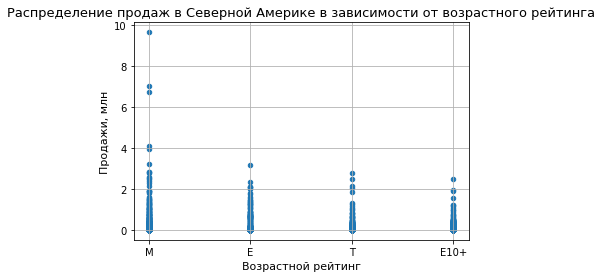

,na_sales
rating,
T,49.79
E10+,54.24
E,79.05
M,165.21


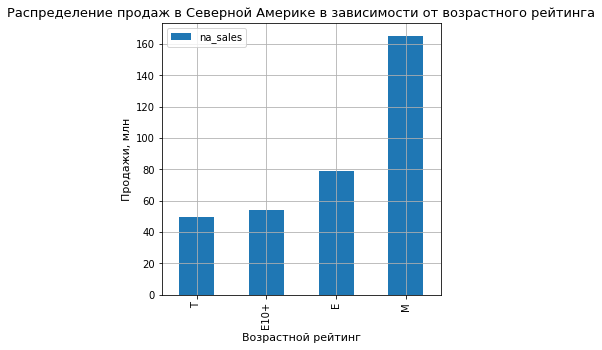

In [71]:
# строим диаграмму рассеивания - зависимость продаж в Северной Америке от возрастного рейтинга
data_rating.plot(x='rating', y='na_sales', kind='scatter', grid=True)
plt.title('Распределение продаж в Северной Америке в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

# делаем свобдную таблицу - группируем по типу оценок и считаем сумму продаж в Северной Америке
data_rating_na = data_filtered.pivot_table(index='rating', values='na_sales', aggfunc='sum')
data_rating_na = data_rating_na.sort_values(by='na_sales', ascending=True)
display(data_rating_na)

# строим столбчатый график
data_rating_na.plot(y='na_sales', kind='bar', figsize=(5, 5), grid=True)
plt.title('Распределение продаж в Северной Америке в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

,na_sales
rating,
0,79.05
10,54.24
13,49.79
17,165.21


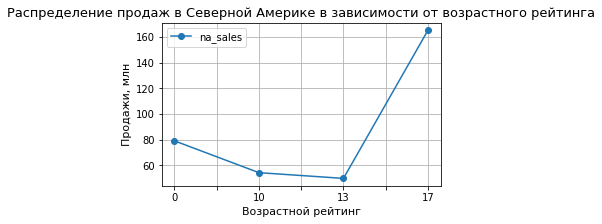

In [72]:
# меняем типы возрастного рейтинга на числовые обозначения, которые соответствуют минимальному 
# возрасту, для построения наглядного графика
data_rating_age = data_rating.copy()
data_rating_age.loc[data_rating['rating'] == 'E', 'rating'] = '0'
data_rating_age.loc[data_rating['rating'] == 'E10+', 'rating'] = '10'
data_rating_age.loc[data_rating['rating'] == 'T', 'rating'] = '13'
data_rating_age.loc[data_rating['rating'] == 'M', 'rating'] = '17'

# делаем свобдную таблицу уже с новым обозначением типов рейтинга
data_rating_na = data_rating_age.pivot_table(index='rating', values='na_sales', aggfunc='sum')
data_rating_na = data_rating_na.sort_values(by='rating')
display(data_rating_na)

# строим линейный график
data_rating_na.plot(y='na_sales', style='o-', figsize=(5,3), grid=True)
plt.title('Распределение продаж в Северной Америке в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

В ходе данного исследования зависимости продаж в Северной Америке от возрастного рейтинга было выявлено следующее:
1) больше всего продаж было сделано игр с возрастным рейтингом M (от 17 лет);\
2) также в данном регионе очень популярны игр с рейтингом E (для всех возрастов);\
3) меньше всего продаж игр с рейтингом T (от 13 лет);\
4) не заметна прямая зависимость между возрастным рейтингом игр и их продажами, нужно рассмотреть другие факторы, влияющие на это.

##### Влияние рейтинга ESRB на продажи в Европе

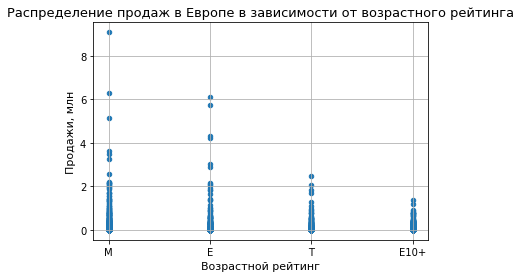

,eu_sales
rating,
T,41.95
E10+,42.69
E,83.36
M,145.32


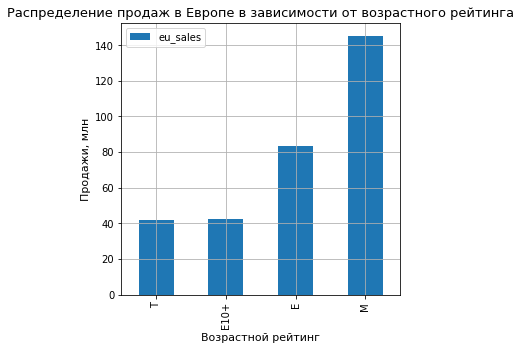

In [73]:
# строим диаграмму рассеивания - зависимость продаж в Европе от возрастного рейтинга
data_rating.plot(x='rating', y='eu_sales', kind='scatter', grid=True)
plt.title('Распределение продаж в Европе в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

# делаем свобдную таблицу - группируем по типу оценок и считаем сумму продаж в Северной Америке
data_rating_eu = data_filtered.pivot_table(index='rating', values='eu_sales', aggfunc='sum')
data_rating_eu = data_rating_eu.sort_values(by='eu_sales', ascending=True)
display(data_rating_eu)

# строим столбчатый график
data_rating_eu.plot(y='eu_sales', kind='bar', figsize=(5, 5), grid=True)
plt.title('Распределение продаж в Европе в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

,eu_sales
rating,
0,83.36
10,42.69
13,41.95
17,145.32


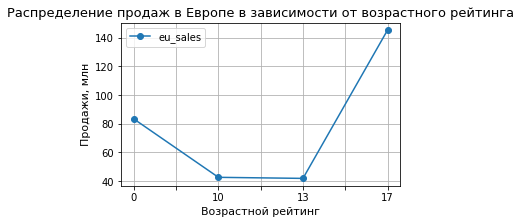

In [74]:
# делаем свобдную таблицу уже с обозначением типов рейтинга числами
data_rating_eu = data_rating_age.pivot_table(index='rating', values='eu_sales', aggfunc='sum')
data_rating_eu = data_rating_eu.sort_values(by='rating')
display(data_rating_eu)

# строим линейный график
data_rating_eu.plot(y='eu_sales', style='o-', figsize=(5,3), grid=True)
plt.title('Распределение продаж в Европе в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

В ходе данного исследования зависимости продаж в Европе от возрастного рейтинга было выявлено следующее:
1) больше всего продаж было сделано игр с возрастным рейтингом M (от 17 лет);\
2) также в данном регионе очень популярны игр с рейтингом E (для всех возрастов);
3) продажи игр с рейтингами E10+ и T примерно на одном уровне;\
4) видна некоторая зависимость между возрастным рейтингом и продажами игр в этом регионе, так наиболее интересные игры с рейтингом M (от 17 лет) самые популярные, а универсальные по возрасту игры с рейтингом E (любой возраст) на втором месте по популярности, а наименее популярные игры предназначены для юных игроков и не особо интересны игрокам взрослым.

##### Влияние рейтинга ESRB на продажи в Японии

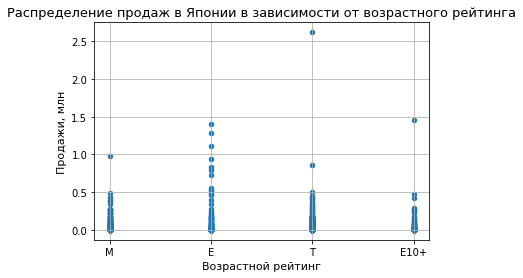

,jp_sales
rating,
E10+,5.89
M,14.11
E,15.14
T,20.59


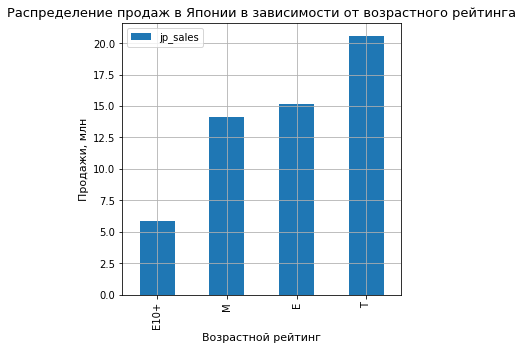

In [75]:
# строим диаграмму рассеивания - зависимость продаж в Японии от возрастного рейтинга
data_rating.plot(x='rating', y='jp_sales', kind='scatter', grid=True)
plt.title('Распределение продаж в Японии в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

# делаем свобдную таблицу - группируем по типу оценок и считаем сумму продаж в Северной Америке
data_rating_jp = data_filtered.pivot_table(index='rating', values='jp_sales', aggfunc='sum')
data_rating_jp = data_rating_jp.sort_values(by='jp_sales', ascending=True)
display(data_rating_jp)

# строим столбчатый график
data_rating_jp.plot(y='jp_sales', kind='bar', figsize=(5, 5), grid=True)
plt.title('Распределение продаж в Японии в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

,jp_sales
rating,
0,15.14
10,5.89
13,20.59
17,14.11


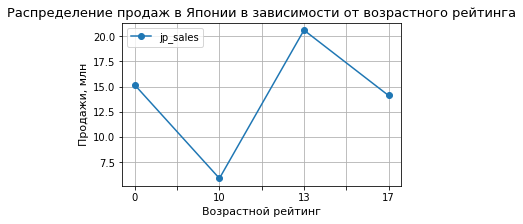

In [76]:
# делаем свобдную таблицу уже с обозначением типов рейтинга числами
data_rating_jp = data_rating_age.pivot_table(index='rating', values='jp_sales', aggfunc='sum')
data_rating_jp = data_rating_jp.sort_values(by='rating')
display(data_rating_jp)

# строим линейный график
data_rating_jp.plot(y='jp_sales', style='o-', figsize=(5,3), grid=True)
plt.title('Распределение продаж в Японии в зависимости от возрастного рейтинга', fontsize=13) # добавила подписи
plt.ylabel('Продажи, млн', fontsize=11)
plt.xlabel('Возрастной рейтинг', fontsize=11)
plt.show()

В ходе данного исследования зависимости продаж в Японии от возрастного рейтинга было выявлено следующее:
1) больше всего продаж было сделано игр с возрастным рейтингом T (от 13 лет);\
2) продажи игр с рейтингами E (все возраста) и M (от 17 лет) примерно на одном уровне;\
3) меньше всего продаж было игр рейтинга E10+ (от 10 лет);\
4) зависимость между возрастным рейтингом и количеством продаж не прослеживается.

##### Вывод

В Северной Америке и Японии зависимость между возрастным рейтингом и продажами игр не прослеживается, при этом в Европе зависимость прослеживается в виде того, что наиболее интересные игры категории M (от 17 лет) и наиболее универсальные по возрасту игры категории E (для всех возрастов) лидируют по продажам, когда как игры для юных игроков наименее популярны.

### Шаг 5. Проверка гипотез

#### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

In [78]:
# делаем выборки отдельно пользватели XOne и отдельно пользователи PC
user_xone = data_filtered.query('platform == "XOne" and user_score.notna()')
user_pc = data_filtered.query('platform == "PC" and user_score.notna()')
print(user_xone.info())
print()
print(user_pc.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 182 entries, 165 to 16660
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             182 non-null    object 
 1   platform         182 non-null    object 
 2   year_of_release  182 non-null    int64  
 3   genre            182 non-null    object 
 4   na_sales         182 non-null    float64
 5   eu_sales         182 non-null    float64
 6   jp_sales         182 non-null    float64
 7   other_sales      182 non-null    float64
 8   critic_score     165 non-null    float64
 9   user_score       182 non-null    float64
 10  rating           176 non-null    object 
 11  total_sales      182 non-null    float64
dtypes: float64(7), int64(1), object(4)
memory usage: 18.5+ KB
None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 155 entries, 458 to 16692
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           -

Нулевая гипотеза - средние пользовательские рейтинги платформ Xbox One и PC одинаковые.\
Альтернативная - средние пользовательские рейтинги платформ Xbox One и PC разные.\
\
Нулевая гипотеза всегда описывает равенство показателей. Альтернативная же может быть двусторонней, как в этом случае, когда проверяется неравенство показателей, или односторонней, когда проверяется отклонение в большую или меньшую сторону.\
\
Проведем двухвыборочный t-тест для двух независимых выборок, потому что t-тест работает для выборок любого размера, к тому же у нас имеются две выборки, равенство средних значений которых нужно статистически проверить.

In [79]:
# выводим средние показатели
print(f'средний пользовательский рейтинг платформы Xbox:',\
      round(user_xone['user_score'].mean(), 1))
print(f'средний пользовательский рейтинг платформы PC:',\
      round(user_pc['user_score'].mean(), 1))
print()

# выбираем уровень статистической значимости
alpha = 0.05

# проводим двухвыборочный t-тест для двух независимых выборок
results = st.ttest_ind(user_xone['user_score'], user_pc['user_score'],\
                       alternative='two-sided')

print('p-значение:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Нулевая гипотеза отвергается.')
else:
    print('Не получилось отвергнуть нулевую гипотезу.')

средний пользовательский рейтинг платформы Xbox: 6.5
средний пользовательский рейтинг платформы PC: 6.3

p-значение: 0.14012658403611647

Не получилось отвергнуть нулевую гипотезу.


Нулевую гипотезу не получилось отвергнуть, значит, средние пользовательские рейтинги платформ Xbox One и PC одинаковы.\
Этот вывод подтверждается маленькой математической разницей в значениях средних пользовательских рейтингов платформы Xbox (6.5) и платформы PC (6.3).

#### Средние пользовательские рейтинги жанров Action  и Sports разные

In [80]:
# делаем выборки отдельно жанров Action и Sports
genre_action = data_filtered.query('genre == "Action" and user_score.notna()')
genre_sports = data_filtered.query('genre == "Sports" and user_score.notna()')
print(genre_action.info())
print()
print(genre_sports.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 389 entries, 16 to 16692
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             389 non-null    object 
 1   platform         389 non-null    object 
 2   year_of_release  389 non-null    int64  
 3   genre            389 non-null    object 
 4   na_sales         389 non-null    float64
 5   eu_sales         389 non-null    float64
 6   jp_sales         389 non-null    float64
 7   other_sales      389 non-null    float64
 8   critic_score     309 non-null    float64
 9   user_score       389 non-null    float64
 10  rating           377 non-null    object 
 11  total_sales      389 non-null    float64
dtypes: float64(7), int64(1), object(4)
memory usage: 39.5+ KB
None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 160 entries, 77 to 16643
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           ---

Нулевая гипотеза - средние пользовательские рейтинги жанров Action и Sports одинаковые.\
Альтернативная - средние пользовательские рейтинги жанров Action и Sports разные.\
\
Нулевая гипотеза всегда описывает равенство показателей. Альтернативная же может быть двусторонней, как в этом случае, когда проверяется неравенство показателей.\
\
Проведем двухвыборочный t-тест для двух независимых выборок, потому что t-тест работает для выборок любого размера, к тому же у нас имеются две выборки, неравенство средних значений которых нужно статистически проверить.

In [81]:
# выводим средние показатели
print(f'средний пользовательский рейтинг жанра Action:',\
      round(genre_action['user_score'].mean(), 1))
print(f'средний пользовательский рейтинг жанра Sports:',\
      round(genre_sports['user_score'].mean(), 1))
print()

# выбираем уровень статистической значимости
alpha = 0.05

# проводим двухвыборочный t-тест для двух независимых выборок
results = st.ttest_ind(genre_action['user_score'], genre_sports['user_score'],\
                       alternative='two-sided')

print('p-значение:', results.pvalue)
print()

if results.pvalue < alpha:
    print('Нулевая гипотеза отвергается.')
else:
    print('Не получилось отвергнуть нулевую гипотезу.')

средний пользовательский рейтинг жанра Action: 6.8
средний пользовательский рейтинг жанра Sports: 5.2

p-значение: 1.0517832389140023e-27

Нулевая гипотеза отвергается.


Нулевую гипотезу получилось отвергнуть, значит, средние пользовательские рейтинги жанров Action и Sports разные.\
Это подтверждается большой разницей в значениях средних пользовательских рейтингов, который у жанра Action равен 6.8, а у жанра Sports - 5.2.

### Шаг 6. Общий вывод

**Исследование проводилось на основе** исторических данных из открытых источников (до 2016 года) о продажах игр, оценках пользователей и экспертов, жанрах и платформах.\
\
\
**Задача была следующая:** нужно было провести исследование и анализ и выявить определяющие успешность игры закономерности, что бы позволило сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.\
\
\
**На этапе предобработки было сделано:**
1) приведение названий столбцов к одному виду;\
2) обработка пропусков;\
3) редактирование типов данных;\
4) обработка дубликатов;\
5) создание столбца с суммарными продажами во всех регионах.
\
\
\
**На этапе исследовательского анализа данных было сделано и выяснено следующее:**
1) выявлен актуальный для данного исследования период, который включил в себя последние 4 года - с 2013 по 2016 гг включительно;\
2) к платформам с наибольшими суммарными продажами за весь период с 1985 года относятся: PS2, X360, PS3, Wii, DS, PS, PS4, GBA, PSP, 3DS (топ-10);\
3) средний срок "жизни" платформы из топа-10 платформ с наибольшими суммарными продажами равен 7 лет;\
4) по продажам за актуальный период с 2013 по 2016 год лидируют платформы PS4 И XOne;\
5) с 2015 по 2016 продажи падали по всем платформам, но с 2013 по 2015 продажи росли у PS4 И XOne, а в период с 2013 по 2014 рост был и на платформах PC и PSV;\
6) наиболее потенциально прибыльными можно считать PS4, XOne, PC, PSV, так как у них на момент 2016 года наблюдается или рост по продажам, или спад не более 60% от продаж в 2013 году;\
7) большее количество продаваемых игр предназначено для платформ: PS4, X360, Wii, XOne, WiiU, PS3, совсем мало для PSP, немногим больше на PSV;\
8) отзывы критиков влияют на продажи игр внутри платформы PS4 в слабой степени, а отзывы пользователей не оказывают никакого влияния на продажи;\
9) оценка критиков влияет на продажи по как минимум по 88.8% платформам в очень слабой или слабой степени влияния и с прямой зависимостью (по шкале Чеддока), оценка пользователей же влияет только в 33.3% случаев, но с большим разбросом в степени влияния (от очень слабого до среднего);\
10) наибольшее количество выпущенных игр в период с 2013 по 2016 год относится к жанру Action, но при этом он входит лишь в топ-7 популярных жанров;\
11) наиболее прибыльным является жанр Shooter, также к самым прибыльным можно отнести жанры Sports и Platform, но с заметной разницей по сравнению с первым;\
12) хотя жанр Role-Playing или RPG по количеству выпущенных игр находится на втором месте, по глобальным продажам он всего на четвертом месте после таких жанров как Platform и Sports, по которым игр было выпущено меньше за этот период;\
12) наименее популярным и прибыльным жанром оказался Adventure.
\
\
\
**Портрет пользователя каждого региона:**\
\
Северная Америка:
* Самые популярные платформы: PS4, XOne, X360, PS3 и 3DS. На них приходится 88% продаж игр за 2013-2016 гг.
* Самые популярные жанры: Action, Shooter, Sports, Role-Playing и Misc. На них приходится 85.7% продаж игр за 2013-2016 гг.\
\
Европа:
* Самые популярные платформы те же: PS4, PS3, XOne, X360 и 3DS, но на них в этом регоне приходится 85,2% продаж за актуальный период.
* Самые популярные жанры: Action, Shooter, Sports, Role-Playing и Racing, на них в этом регоне приходится 82.4% продаж.\
\
Япония:
* Самые популярные платформы: 3DS, PS3, PSV, PS4, WiiU, на них приходится 97% продаж.
* Самые популярные жанры: Role-Playing, Action, Misc, Fighting, Shooter, на которые приходится 81.7% продаж.
<br>
<br>
<br>

**Влияние рейтинга ESRB на продажи в отдельном регионе:**

В Северной Америке и Японии зависимость между возрастным рейтингом и продажами игр не прослеживается.\
В Европе зависимость прослеживается в виде того, что наиболее интересные игры категории M (от 17 лет) и наиболее универсальные по возрасту игры категории E (для всех возрастов) лидируют по продажам, когда как игры для юных игроков наименее популярны.<br>
<br>

**Заключение после проверки гипотез:**
1. Средние пользовательские рейтинги платформ Xbox One и PC одинаковые.
2. Средние пользовательские рейтинги жанров Action и Sports разные.<br>
<br>


**Возможные рекомендации:**\
Наиболее перспективными для успешной рекламной кампании можно назвать игры, предназначенные для платформ PS4 и XOne жанра Shooter, имеющие рейтинг ESRB M или E, при этом стоит обратить внимание на отзывы критиков, так как они в некоторой степени тоже влияют на продажи; также хочу заметить, что рекламную кампанию будет выгоднее проводить только в Северной Америке и Европе, так как в Японии данные платформы и жанры не популярны.